<a href="https://colab.research.google.com/github/shibukawar/stein-importance-sampling-qa/blob/feature%2Fstein-importance-sampling/notebook/example_stein_importance_sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demo

Sample program for the stein importance sampling.

Using the kernelized stein discrepancy, one can correct samples from **any** distribution into samples of target distribution.

In this notebook, a demonstration that the target distribution $h(x)$ is approximated using samples from $p(x)$ is performed.

$$p(x) = \frac{1}{Z} \exp (-\beta H(x)), \beta = 0.1$$

$$h(x) = \frac{1}{Z} \exp (-\beta H(x)), \beta = 1.0$$

$$H(x) = ( a_1^⊤ x - t_1)^2 + ( a_2^⊤ x - t_2)^2, \\a_1 = (1, 1, 1, 1, 1, 1)^\top, a_2 = (1, 1, 1, 0, 0, 0)^\top \\ t_1 = 3, t_2 = 2$$

A point is that you can obtain the true distribution without knowing the variable $Z$ using the actual samples.

In [1]:
import os
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from dimod.vartypes import Vartype

from stein.energy import create_hamiltonian, random_energy, sample_energy
from stein.kernel import KernelType
from stein.ksd import DiscreteKSD
from stein.stats import GibbsDistribution

In [2]:
# Define hyperparameters
num = 1000
dim = 6

ub = 2**dim

sbeta = 0.1  # sampling temperature

beta = 1  # target temperature

energy = sample_energy()
# energy = random_energy(dim)
ht = GibbsDistribution(energy, beta, dim, compute_pmf=True, vartype=Vartype.BINARY)
hs = GibbsDistribution(energy, sbeta, dim, compute_pmf=True, vartype=Vartype.BINARY)

# Define a target and a sampling distribution

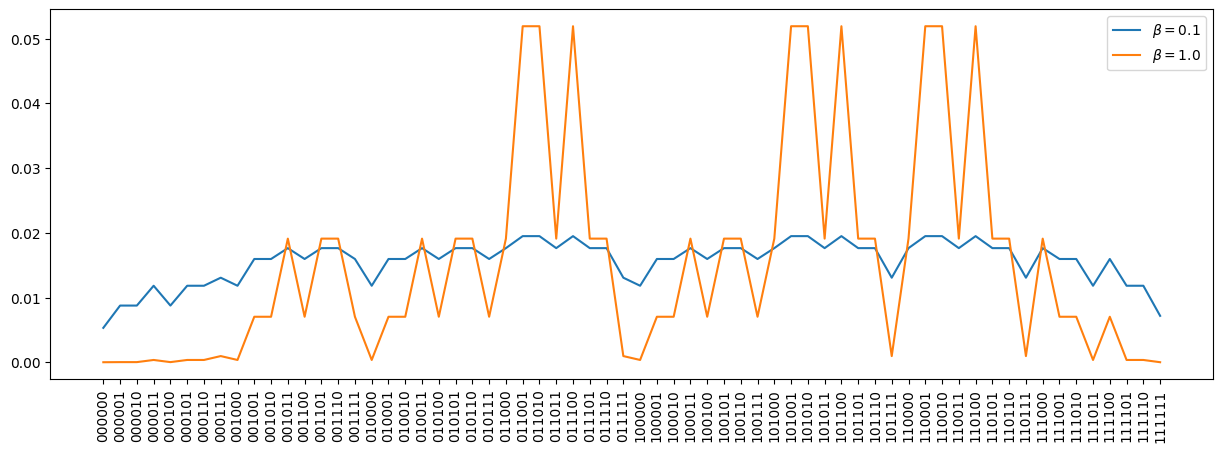

In [3]:
# Enumerate all possible state for a binary vector in {0, 1}^6
# 2 ^ 6 patterns
ps = np.zeros(ub)
energies = np.zeros(ub, dtype=int)
pt = np.zeros(ub)

all_state = []
for i in range(ub):
    # Convert integer into 6 bit binary
    y = format(i, f"0{dim}b")
    all_state.append(y)
    # z denotes a state: e.x. [0, 1, 0, 0, 1, 0]
    z = np.zeros(dim, dtype="i1")
    for j in range(dim):
        z[j] = int(y[j])
#     print(z, energy(z))
    ps[i] = hs.pmf(z)
    pt[i] = ht.pmf(z)


# Plot the distributions
fig = plt.figure(figsize=(15, 4.8))
plt.xticks(range(ub), all_state, rotation=90)
plt.plot(ps, label=r"$\beta = 0.1$")
plt.plot(pt, label=r"$\beta = 1.0$")
plt.legend()

In [4]:
# sampling
samples = []
state_to_prob = {}
samples_binary = []
for i in range(num):
    a = random.choices(np.arange(ub), ps)[0]
    x = np.zeros(dim, dtype="i1")
    y = format(a, f"0{dim}b")
    for j in range(dim):
        x[j] = int(y[j])
    samples.append(x)
    samples_binary.append(y)
    if tuple(x) not in state_to_prob.keys():
        state_to_prob[tuple(x)] = [0, ps[a], pt[a]]
    state_to_prob[tuple(x)][0] += 1
print(len(samples))

1000


In [5]:
# note: compute_pmf = False
# trg does not have exact probability.
trg = GibbsDistribution(energy, beta, dim, compute_pmf=False, vartype=Vartype.BINARY)
ksd = DiscreteKSD(dim=dim, kernel_type=KernelType.Hamming, distrib=trg, vartype=Vartype.BINARY)

In [6]:
dim

6

In [7]:
X = np.array(list(state_to_prob.keys()))
w = np.array([state_to_prob[tuple(x)][0] for x in X])
w = np.ones(len(X))

In [8]:
start = w / sum(w)

In [9]:
# ksd.fit(X, w)
ksd.fit_egd(X, n_iter=20000, eta=0.01, feature_dim=5000)
sum(ksd.weight)

1.0

In [10]:
corrected_distribution = ksd.weight
sample_distribution = np.array([state_to_prob[tuple(x)][1] for x in X])
target_distribution = np.array([state_to_prob[tuple(x)][2] for x in X])
idx = np.argsort(-target_distribution)

p_corr = np.zeros(ub)
for i, x in enumerate(X):
    y = sum(list(map(lambda i: 2 ** (dim - 1 - i) * x[i], range(dim))))
    #     print(i, x, corrected_distribution[i])
    p_corr[y] = corrected_distribution[i]

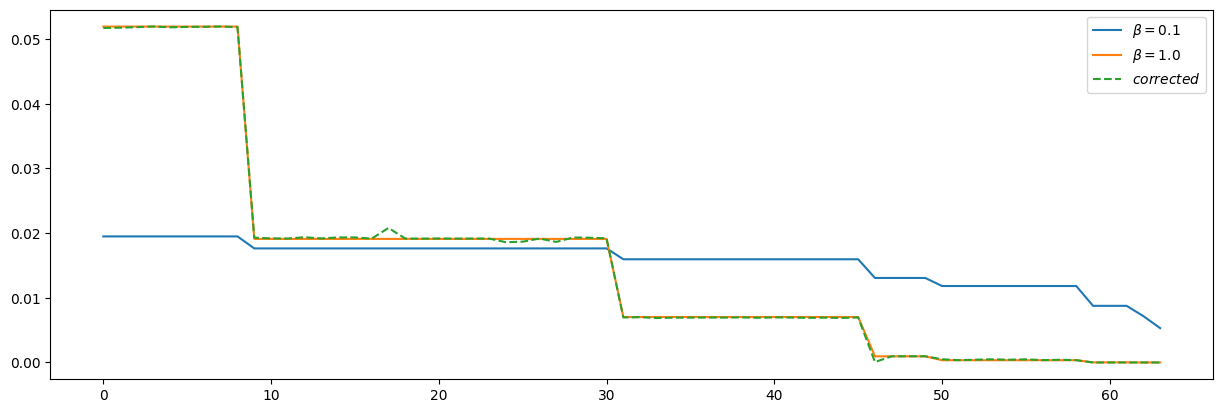

In [11]:
fig = plt.figure(figsize=(15, 4.8))
plt.plot(
    range(len(sample_distribution)), sample_distribution[idx], label=r"$\beta = 0.1$"
)
plt.plot(
    range(len(sample_distribution)), target_distribution[idx], label=r"$\beta = 1.0$"
)
plt.plot(
    range(len(sample_distribution)), corrected_distribution[idx], '--', label=r"$corrected$"
)
plt.legend()

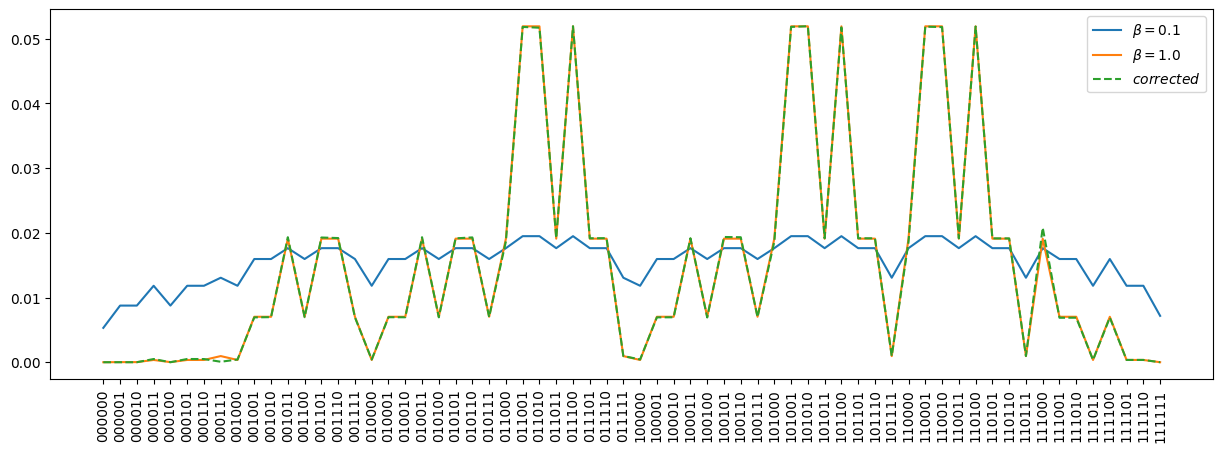

In [12]:
# Plot the distributions
fig = plt.figure(figsize=(15, 4.8))
plt.xticks(range(ub), all_state, rotation=90)
plt.plot(ps, label=r"$\beta = 0.1$")
plt.plot(pt, label=r"$\beta = 1.0$")
plt.plot(p_corr, '--', label=r"$corrected$")
plt.legend()